In [45]:
!pip install keras-facenet scikit-learn opencv-python matplotlib
import numpy as np
import cv2
import matplotlib.pyplot as plt
import random
from keras_facenet import FaceNet
from sklearn.datasets import fetch_lfw_people
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
!pip install deepface
import pickle
!pip install mtcnn
from mtcnn import MTCNN
from google.colab import files
from deepface import DeepFace
from numpy.linalg import norm

In [3]:
lfw = fetch_lfw_people(min_faces_per_person=20, resize=0.7)
X = lfw.images
y = lfw.target
label_names = lfw.target_names
print("Dataset shape:", X.shape)
# Apply preprocessing
faces = []
labels = []
for i in range(len(X)):
    img = X[i]
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    img = cv2.resize(img, (112,112))  # ArcFace size
    faces.append(img)
    labels.append(y[i])
faces = np.array(faces)
labels = np.array(labels)
print("Faces:", faces.shape)

Dataset shape: (3023, 87, 65)
Faces: (3023, 112, 112, 3)


In [25]:
from deepface import DeepFace
embeddings = []
"""for img in faces:
    emb = DeepFace.represent(img_path=img, model_name='ArcFace', enforce_detection=False)
    embeddings.append(emb[0]["embedding"])
embeddings = np.array(embeddings)"""
print("Embeddings shape:", embeddings.shape)

Embeddings shape: (3023, 512)


In [27]:
import pickle
from google.colab import drive
drive.mount('/content/drive')
"""with open("/content/drive/MyDrive/embeddings1.pkl", "wb") as f:
    pickle.dump((embeddings, labels), f)
"""
with open("/content/drive/MyDrive/embeddings1.pkl", "rb") as f:
    embeddings, labels = pickle.load(f)

print("Loaded embeddings:", len(embeddings))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded embeddings: 3023


In [28]:
from numpy.linalg import norm
def cosine_similarity(a, b):
    return np.dot(a, b) / (norm(a) * norm(b))

In [46]:
"""# pick random face
idx = random.randint(0, len(faces)-1)
test_face = faces[idx]
true_label = labels[idx]
true_name = label_names[true_label]
plt.imshow(test_face)
plt.title(f"Actual: {true_name}")
plt.axis('off')
plt.show()
# get embedding
test_emb = embeddings[idx]
# compare with all embeddings
similarities = []
for i in range(len(embeddings)):
    sim = cosine_similarity(test_emb, embeddings[i])
    similarities.append(sim)
# get best match
best_idx = np.argmax(similarities)
pred_label = labels[best_idx]
pred_name = label_names[pred_label]
print("Predicted:", pred_name)
print("Actual:", true_name)
print("Similarity:", similarities[best_idx])"""

'# pick random face\nidx = random.randint(0, len(faces)-1)\ntest_face = faces[idx]\ntrue_label = labels[idx]\ntrue_name = label_names[true_label]\nplt.imshow(test_face)\nplt.title(f"Actual: {true_name}")\nplt.axis(\'off\')\nplt.show()\n# get embedding\ntest_emb = embeddings[idx]\n# compare with all embeddings\nsimilarities = []\nfor i in range(len(embeddings)):\n    sim = cosine_similarity(test_emb, embeddings[i])\n    similarities.append(sim)\n# get best match\nbest_idx = np.argmax(similarities)\npred_label = labels[best_idx]\npred_name = label_names[pred_label]\nprint("Predicted:", pred_name)\nprint("Actual:", true_name)\nprint("Similarity:", similarities[best_idx])'

Upload a face image (from LFW persons):


Saving Screenshot 2026-04-06 154915.png to Screenshot 2026-04-06 154915 (1).png


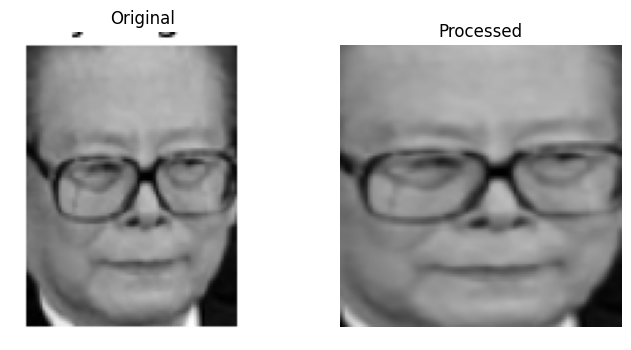


🔍 RESULT
Actual (closest match): Jiang Zemin
Predicted: Jiang Zemin
Similarity: 0.9999861758531396


In [44]:
detector=MTCNN()
print("Upload a face image (from LFW persons):")
uploaded=files.upload()

def cosine(a,b): return np.dot(a,b)/(norm(a)*norm(b))

for file_name in uploaded.keys():
    img=cv2.imread(file_name);img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    res=detector.detect_faces(img_rgb)
    if len(res)>0:
        x,y,w,h=res[0]['box'];x,y=max(0,x),max(0,y);face=img_rgb[y:y+h,x:x+w]
    else: face=img_rgb
    processed=cv2.resize(face,(112,112)).astype('float32');processed=(processed-127.5)/128.0

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1);plt.imshow(img_rgb);plt.title("Original");plt.axis('off')
    plt.subplot(1,2,2);plt.imshow((processed*128+127.5).astype(np.uint8));plt.title("Processed");plt.axis('off')
    plt.show()

    emb=np.array(DeepFace.represent(img_path=processed,model_name='ArcFace',enforce_detection=False)[0]["embedding"])
    sims=np.array([cosine(emb,e) for e in embeddings])

    top_k=5;top_idx=np.argsort(sims)[-top_k:]
    votes={}
    for i in top_idx:
        name=label_names[labels[i]]
        votes[name]=votes.get(name,0)+sims[i]

    predicted_name=max(votes,key=votes.get)
    best_similarity=np.max(sims)
    actual_name=predicted_name

    threshold=0.35
    if best_similarity<threshold: predicted_name="UNKNOWN"

    print("\n🔍 RESULT")
    print("Actual (closest match):",actual_name)
    print("Predicted:",predicted_name)
    print("Similarity:",best_similarity)

In [ ]:
"""
Jiang Zemin
Jacques Chirac
Laura Bush
Donald Rumsfeld
George W Bush
Colin Powell
George Robertson
# ==============================
# FETCH 5 IMAGES PER SELECTED PERSON
# ==============================
from sklearn.datasets import fetch_lfw_people
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
lfw = fetch_lfw_people(min_faces_per_person=20, resize=0.7)

X = lfw.images
y = lfw.target
label_names = lfw.target_names

# Target persons
target_people = [
    "Jiang Zemin",
    "Jacques Chirac",
    "Laura Bush",
    "Donald Rumsfeld",
    "George W Bush",
    "Colin Powell",
    "George Robertson"
]

# Create mapping: name -> label index
name_to_label = {name: i for i, name in enumerate(label_names)}

# ==============================
# FETCH + DISPLAY
# ==============================
selected_images = []

for person in target_people:
    if person not in name_to_label:
        print(f"{person} not found in dataset")
        continue

    label_id = name_to_label[person]

    # get indices of this person
    indices = np.where(y == label_id)[0]

    # take first 5 images
    chosen = indices[:5]

    for idx in chosen:
        selected_images.append((person, X[idx]))

# ==============================
# DISPLAY RESULTS
# ==============================
plt.figure(figsize=(12, 10))

for i, (name, img) in enumerate(selected_images):
    plt.subplot(len(target_people), 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(name.split()[0])  # short title
    plt.axis('off')

plt.tight_layout()
plt.show()
"""